<a href="https://colab.research.google.com/github/BrunoBucCcellati/MachineLearningUNN2025/blob/main/Task7_Deryabin_M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

УСТАНОВКА БИБЛИОТЕК И НАСТРОЙКА СРЕДЫ
Библиотеки успешно импортированы. Начинаем анализ...


[ЭТАП 1] ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
------------------------------------------------------------
• Объём исходного датасета: 110,811 записей
• Используемая выборка для анализа: 60,000 записей
• Количество признаков: 8

Первые 3 записи:
   patient_id     drugname                    condition  \
0      211662  Lamotrigine              bipolar disorde   
1      212538       Lysine  herpes simplex, suppression   
2      200470  Varenicline            smoking cessation   

                                              review  rating  \
0  "I started on Lamictal after having manic epis...    10.0   
1  "There is no cure for HSV2 but you can suppres...     8.0   
2  "March 26 2013, I will be smoke free for 3 yea...    10.0   

                date  usefulcount  review_length  
0      July 10, 2017           39            131  
1   December 4, 2017            2            125  
2  December 31, 

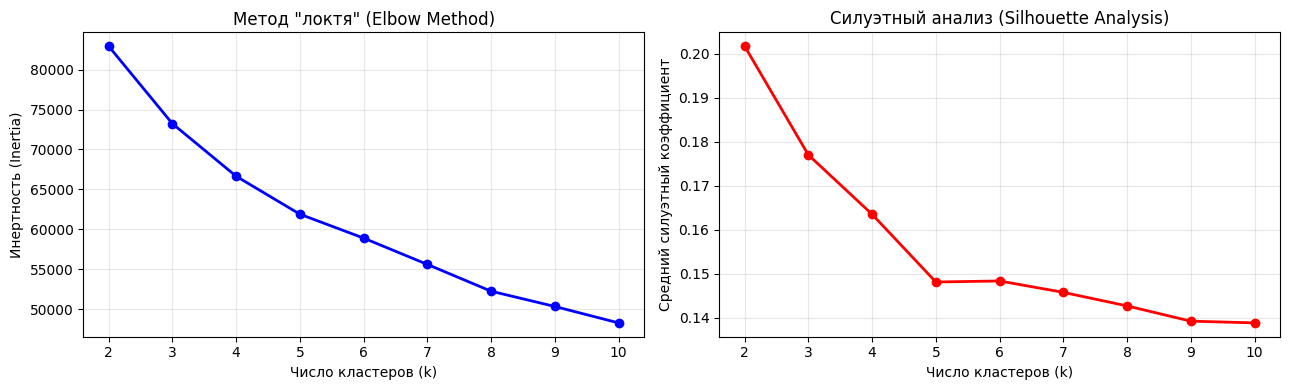

• Оптимальное число кластеров (по силуэтному коэффициенту): k = 2

[ЭТАП 5] ВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ ТРЕМЯ АЛГОРИТМАМИ
------------------------------------------------------------
• K-Means: 2 кластера


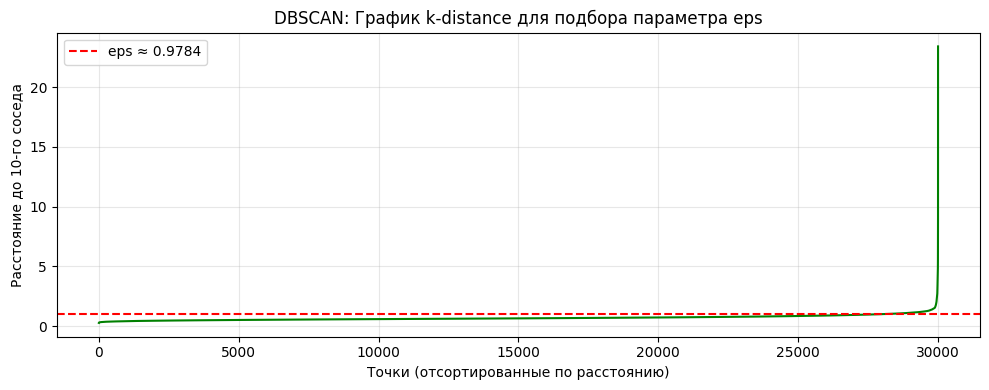

• DBSCAN: 3 кластера, шум: 718 точек (2.4%)
• Параметры DBSCAN: eps=0.9784, min_samples=10
• Birch: 2 кластера

[ЭТАП 6] ОЦЕНКА ВНУТРЕННЕГО КАЧЕСТВА КЛАСТЕРИЗАЦИИ
------------------------------------------------------------

Сравнительная таблица метрик качества:
 Метод Silhouette Calinski-Harabasz Davies-Bouldin
KMeans     0.2132           17082.7         1.7834
DBSCAN     0.0424              17.5         1.0521
 Birch     0.1759           13305.2         1.9897

[ЭТАП 7] СРАВНЕНИЕ КЛАСТЕРОВ С ИСТИННОЙ КЛАССИФИКАЦИЕЙ
------------------------------------------------------------
• Распределение классов рейтинга: Низкий (0): 14597, Средний (1): 9077, Высокий (2): 36326

Метрики согласованности с истинными классами:
 Метод Adjusted Rand Index (ARI) Normalized Mutual Info (NMI)
KMeans                  0.000158                     0.000302
DBSCAN                 -0.000179                     0.000179
 Birch                 -0.000525                     0.001086

[ЭТАП 8] ВИЗУАЛИЗАЦИЯ КЛАСТЕ

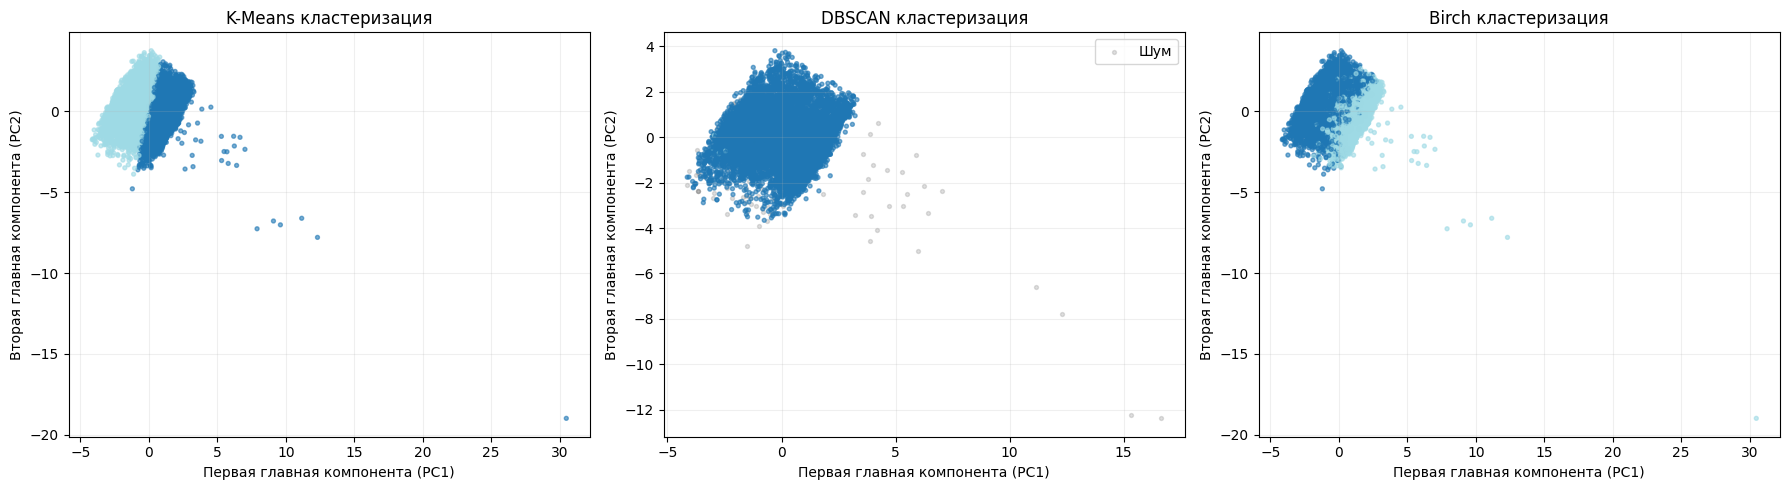


[ЭТАП 9] АНАЛИЗ ХАРАКТЕРИСТИК КЛАСТЕРОВ (НА ПРИМЕРЕ K-MEANS)
------------------------------------------------------------
Статистические характеристики кластеров K-Means:
               usefulcount               review_len_word         \
                     count   mean median            mean median   
cluster_kmeans                                                    
0                    30034  26.51   14.0      126.800003  130.0   
1                    29966  30.85   19.0       63.549999   63.0   

               review_len_char        rating         
                          mean median   mean median  
cluster_kmeans                                       
0                   670.440002  702.0   7.00    8.0  
1                   338.079987  332.0   7.03    8.0  

Топ-3 лекарств в каждом кластере K-Means:
  Кластер 0: ['Levonorgestrel', 'Etonogestrel', 'Ethinyl estradiol / norethindrone']
  Кластер 1: ['Ethinyl estradiol / norethindrone', 'Etonogestrel', 'Levonorgestrel']

ОБСУЖДЕН

In [4]:
# ============================================================
# Лабораторная работа №3. Кластерный анализ отзывов о лекарствах
# Датасет: Drug-Review-Dataset (Hugging Face)
# Автор: Дерябин Максим Сергеевич
# Группа: ПМиИ 3822Б1ПМоп3
# ============================================================

"""
АНАЛИЗ МЕТОДОВ КЛАСТЕРИЗАЦИИ

В данной работе применяются три принципиально разных подхода к кластеризации:

1. K-MEANS
   • Принцип: минимизация внутрикластерной дисперсии
   • Преимущества: скорость, интерпретируемость, масштабируемость
   • Недостатки: требует задания числа кластеров, чувствителен к выбросам
   • Применение: базовая сегментация данных

2. DBSCAN (Density-Based Spatial Clustering)
   • Принцип: выделение областей высокой плотности
   • Преимущества: не требует задания числа кластеров, устойчив к шуму
   • Недостатки: чувствителен к параметрам eps и min_samples
   • Применение: обнаружение аномалий и кластеров произвольной формы

3. BIRCH (Balanced Iterative Reducing and Clustering)
   • Принцип: иерархическое построение CF-дерева
   • Преимущества: экстремальная скорость на больших данных
   • Недостатки: может уступать в точности на малых выборках
   • Применение: обработка очень крупных датасетов

ОСОБЕННОСТИ РЕАЛИЗАЦИИ В ДАННОЙ РАБОТЕ:
• PCA применяется для: 1) ускорения вычислений, 2) визуализации
• Метрики качества: Silhouette, Calinski-Harabasz, Davies-Bouldin
• Сравнение с "истинными" метками: ARI и NMI относительно категоризованного рейтинга
"""

# Установка и импорт библиотек
print("="*80)
print("УСТАНОВКА БИБЛИОТЕК И НАСТРОЙКА СРЕДЫ")
print("="*80)

!pip -q install datasets scikit-learn pandas numpy matplotlib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import MiniBatchKMeans, DBSCAN, Birch
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Конфигурация для управления производительностью
N_USE = 60000
N_DBSCAN = 30000
N_SIL_SAMPLE = 5000
N_VIS = 8000
K_RANGE = list(range(2, 11))
DBSCAN_MIN_SAMPLES = 10
DBSCAN_EPS_PERCENTILE = 92

print("Библиотеки успешно импортированы. Начинаем анализ...")
print("\n" + "="*80)

# ============================================================================
# 1. ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ
# ============================================================================

print("\n[ЭТАП 1] ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")
print("-" * 60)

ds = load_dataset("forwins/Drug-Review-Dataset", split="train")
n_total = len(ds)
ds_small = ds.shuffle(seed=RANDOM_STATE).select(range(min(N_USE, n_total)))
df = ds_small.to_pandas()
df.columns = [c.lower() for c in df.columns]

print(f"• Объём исходного датасета: {n_total:,} записей")
print(f"• Используемая выборка для анализа: {df.shape[0]:,} записей")
print(f"• Количество признаков: {df.shape[1]}")
print("\nПервые 3 записи:")
print(df.head(3))

# ============================================================================
# 2. ИНЖЕНЕРИЯ ПРИЗНАКОВ (БЕЗ ИСПОЛЬЗОВАНИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ)
# ============================================================================

print("\n[ЭТАП 2] ФОРМИРОВАНИЕ ПРИЗНАКОВ ДЛЯ КЛАСТЕРИЗАЦИИ")
print("-" * 60)

df_work = df.copy()

# Текстовые признаки
df_work["review"] = df_work["review"].fillna("").astype(str)
df_work["review_len_char"] = df_work["review"].str.len().astype(np.float32)
df_work["review_len_word"] = df_work["review"].str.split().str.len().astype(np.float32)

# Временные признаки
df_work["date_parsed"] = pd.to_datetime(df_work["date"], errors="coerce")
df_work["year"] = df_work["date_parsed"].dt.year.astype(np.float32)
df_work["month"] = df_work["date_parsed"].dt.month.astype(np.float32)

# Признак полезности с логарифмированием
df_work["usefulcount"] = pd.to_numeric(df_work["usefulcount"], errors="coerce").astype(np.float32)
df_work["usefulcount_log"] = np.log1p(df_work["usefulcount"]).astype(np.float32)

# Частотное кодирование категориальных признаков
for col in ["drugname", "condition"]:
    if col in df_work.columns:
        vc = df_work[col].fillna("UNKNOWN").value_counts(dropna=False)
        freq_map = vc.to_dict()
        df_work[f"{col}_freq"] = df_work[col].fillna("UNKNOWN").map(freq_map).astype(np.float32)
        df_work[f"{col}_freq_log"] = np.log1p(df_work[f"{col}_freq"]).astype(np.float32)

# Итоговый набор признаков
feature_cols = [
    "usefulcount_log", "review_len_char", "review_len_word",
    "year", "month", "drugname_freq_log", "condition_freq_log"
]
feature_cols = [c for c in feature_cols if c in df_work.columns]

print(f"• Сформировано признаков: {len(feature_cols)}")
print(f"• Список признаков: {feature_cols}")

# Подготовка матрицы признаков
X_raw = imputer.fit_transform(df_work[feature_cols]).astype(np.float32)
rating = pd.to_numeric(df_work["rating"], errors="coerce").astype(np.float32)

# ============================================================================
# 3. НОРМАЛИЗАЦИЯ И СНИЖЕНИЕ РАЗМЕРНОСТИ
# ============================================================================

print("\n[ЭТАП 3] ПРЕДОБРАБОТКА И УМЕНЬШЕНИЕ РАЗМЕРНОСТИ (PCA)")
print("-" * 60)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

# PCA для кластеризации (сохранение 95% дисперсии)
pca_cluster = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca_cluster.fit_transform(X_scaled).astype(np.float32)
explained_var = float(np.sum(pca_cluster.explained_variance_ratio_))

# PCA для визуализации (2D)
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_scaled).astype(np.float32)

print(f"• Исходная размерность: {X_scaled.shape[1]} признаков")
print(f"• Размерность после PCA (95% дисперсии): {X_pca.shape[1]} компонент")
print(f"• Объяснённая дисперсия: {explained_var:.2%}")
print(f"• 2D-PCA объясняет {np.sum(pca_2d.explained_variance_ratio_):.2%} дисперсии")

# ============================================================================
# 4. ПОДБОР ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ (K-MEANS)
# ============================================================================

print("\n[ЭТАП 4] ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ")
print("-" * 60)

n_for_k = min(len(X_pca), max(N_SIL_SAMPLE * 3, 12000))
idx_k = np.random.choice(len(X_pca), size=n_for_k, replace=False)
X_pca_k = X_pca[idx_k]

inertias, sil_scores = [], []
for k in K_RANGE:
    model = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=2048, n_init=10)
    labels = model.fit_predict(X_pca_k)
    inertias.append(float(model.inertia_))
    sil = silhouette_score(X_pca_k, labels, sample_size=min(N_SIL_SAMPLE, len(X_pca_k)), random_state=RANDOM_STATE)
    sil_scores.append(float(sil))

# Визуализация методов "локтя" и силуэта
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(K_RANGE, inertias, marker="o", color='blue', linewidth=2)
ax1.set_title('Метод "локтя" (Elbow Method)')
ax1.set_xlabel("Число кластеров (k)")
ax1.set_ylabel("Инертность (Inertia)")
ax1.grid(True, alpha=0.3)

ax2.plot(K_RANGE, sil_scores, marker="o", color='red', linewidth=2)
ax2.set_title("Силуэтный анализ (Silhouette Analysis)")
ax2.set_xlabel("Число кластеров (k)")
ax2.set_ylabel("Средний силуэтный коэффициент")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

k_opt = K_RANGE[int(np.argmax(sil_scores))]
print(f"• Оптимальное число кластеров (по силуэтному коэффициенту): k = {k_opt}")

# ============================================================================
# 5. ПРИМЕНЕНИЕ ТРЁХ МЕТОДОВ КЛАСТЕРИЗАЦИИ
# ============================================================================

print("\n[ЭТАП 5] ВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ ТРЕМЯ АЛГОРИТМАМИ")
print("-" * 60)

# 5.1 K-Means
kmeans = MiniBatchKMeans(n_clusters=k_opt, random_state=RANDOM_STATE, batch_size=4096, n_init=20)
labels_kmeans = kmeans.fit_predict(X_pca)
print(f"• K-Means: {len(np.unique(labels_kmeans))} кластера")

# 5.2 DBSCAN (на подвыборке для производительности)
n_db = min(N_DBSCAN, len(X_pca))
idx_db = np.random.RandomState(RANDOM_STATE).choice(len(X_pca), size=n_db, replace=False)
X_pca_db = X_pca[idx_db]

# Подбор параметра eps
nn = NearestNeighbors(n_neighbors=DBSCAN_MIN_SAMPLES, n_jobs=-1)
nn.fit(X_pca_db)
distances, _ = nn.kneighbors(X_pca_db)
k_dist = np.sort(distances[:, DBSCAN_MIN_SAMPLES - 1])
eps = float(np.percentile(k_dist, DBSCAN_EPS_PERCENTILE))

# Визуализация k-distance графика
plt.figure(figsize=(10, 4))
plt.plot(k_dist, color='green', linewidth=1.5)
plt.axhline(eps, linestyle="--", color='red', label=f"eps ≈ {eps:.4f}")
plt.title("DBSCAN: График k-distance для подбора параметра eps")
plt.xlabel("Точки (отсортированные по расстоянию)")
plt.ylabel(f"Расстояние до {DBSCAN_MIN_SAMPLES}-го соседа")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Применение DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X_pca_db)
n_noise = int(np.sum(labels_dbscan == -1))
n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)

print(f"• DBSCAN: {n_clusters_db} кластера, шум: {n_noise} точек ({n_noise/len(labels_dbscan):.1%})")
print(f"• Параметры DBSCAN: eps={eps:.4f}, min_samples={DBSCAN_MIN_SAMPLES}")

# 5.3 Birch
birch = Birch(n_clusters=k_opt, threshold=0.5)
labels_birch = birch.fit_predict(X_pca)
print(f"• Birch: {len(np.unique(labels_birch))} кластера")

# ============================================================================
# 6. ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ
# ============================================================================

print("\n[ЭТАП 6] ОЦЕНКА ВНУТРЕННЕГО КАЧЕСТВА КЛАСТЕРИЗАЦИИ")
print("-" * 60)

def calculate_metrics(X, labels, name):
    labels, X = np.asarray(labels), np.asarray(X)

    if name == "DBSCAN":
        mask = labels != -1
        if mask.sum() < 10 or len(np.unique(labels[mask])) < 2:
            return {"Метод": name, "Silhouette": np.nan, "Calinski-Harabasz": np.nan, "Davies-Bouldin": np.nan}
        X2, y2 = X[mask], labels[mask]
        sil = silhouette_score(X2, y2, sample_size=min(N_SIL_SAMPLE, len(X2)), random_state=RANDOM_STATE)
        ch = calinski_harabasz_score(X2, y2)
        db = davies_bouldin_score(X2, y2)
    else:
        if len(np.unique(labels)) < 2:
            return {"Метод": name, "Silhouette": np.nan, "Calinski-Harabasz": np.nan, "Davies-Bouldin": np.nan}
        sil = silhouette_score(X, labels, sample_size=min(N_SIL_SAMPLE, len(X)), random_state=RANDOM_STATE)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)

    return {"Метод": name, "Silhouette": float(sil), "Calinski-Harabasz": float(ch), "Davies-Bouldin": float(db)}

# Сбор метрик для всех методов
metrics_results = [
    calculate_metrics(X_pca, labels_kmeans, "KMeans"),
    calculate_metrics(X_pca_db, labels_dbscan, "DBSCAN"),
    calculate_metrics(X_pca, labels_birch, "Birch")
]

metrics_df = pd.DataFrame(metrics_results)
print("\nСравнительная таблица метрик качества:")
print(metrics_df.to_string(index=False, formatters={
    "Silhouette": "{:.4f}".format,
    "Calinski-Harabasz": "{:.1f}".format,
    "Davies-Bouldin": "{:.4f}".format
}))

# ============================================================================
# 7. СРАВНЕНИЕ С "ИСТИННЫМИ" МЕТКАМИ (РЕЙТИНГ -> КЛАССЫ)
# ============================================================================

print("\n[ЭТАП 7] СРАВНЕНИЕ КЛАСТЕРОВ С ИСТИННОЙ КЛАССИФИКАЦИЕЙ")
print("-" * 60)

# Преобразование рейтинга в 3 класса
y_true = pd.cut(rating, bins=[0, 4, 7, 10], labels=[0, 1, 2], include_lowest=True).astype(int).to_numpy()
y_true_db = y_true[idx_db]

print(f"• Распределение классов рейтинга: Низкий (0): {(y_true==0).sum()}, Средний (1): {(y_true==1).sum()}, Высокий (2): {(y_true==2).sum()}")

def compare_with_true(y_true_local, cluster_labels, name):
    cluster_labels, y_true_local = np.asarray(cluster_labels), np.asarray(y_true_local)

    if name == "DBSCAN":
        mask = cluster_labels != -1
        if mask.sum() == 0:
            return {"Метод": name, "ARI": np.nan, "NMI": np.nan}
        ari = adjusted_rand_score(y_true_local[mask], cluster_labels[mask])
        nmi = normalized_mutual_info_score(y_true_local[mask], cluster_labels[mask])
    else:
        ari = adjusted_rand_score(y_true_local, cluster_labels)
        nmi = normalized_mutual_info_score(y_true_local, cluster_labels)

    return {"Метод": name, "Adjusted Rand Index (ARI)": float(ari), "Normalized Mutual Info (NMI)": float(nmi)}

# Сравнение для всех методов
comparison_results = [
    compare_with_true(y_true, labels_kmeans, "KMeans"),
    compare_with_true(y_true_db, labels_dbscan, "DBSCAN"),
    compare_with_true(y_true, labels_birch, "Birch")
]

comparison_df = pd.DataFrame(comparison_results)
print("\nМетрики согласованности с истинными классами:")
print(comparison_df.to_string(index=False, formatters={
    "Adjusted Rand Index (ARI)": "{:.6f}".format,
    "Normalized Mutual Info (NMI)": "{:.6f}".format
}))

# ============================================================================
# 8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================================

print("\n[ЭТАП 8] ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ В 2D-ПРОСТРАНСТВЕ (PCA)")
print("-" * 60)

# Подготовка данных для визуализации
n_vis = min(N_VIS, len(X_2d))
idx_vis = np.random.RandomState(RANDOM_STATE).choice(len(X_2d), size=n_vis, replace=False)
X_vis, labels_k_vis, labels_b_vis = X_2d[idx_vis], labels_kmeans[idx_vis], labels_birch[idx_vis]

X_db_vis2d = X_2d[idx_db]
n_vis_db = min(n_vis, len(X_db_vis2d))
idx_vis_db = np.random.RandomState(RANDOM_STATE).choice(len(X_db_vis2d), size=n_vis_db, replace=False)
X_db_vis, labels_db_vis = X_db_vis2d[idx_vis_db], labels_dbscan[idx_vis_db]

# Построение графиков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KMeans
scatter_kmeans = axes[0].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_k_vis, s=8, alpha=0.6, cmap='tab20')
axes[0].set_title("K-Means кластеризация")
axes[0].set_xlabel("Первая главная компонента (PC1)")
axes[0].set_ylabel("Вторая главная компонента (PC2)")
axes[0].grid(True, alpha=0.2)

# DBSCAN
noise = labels_db_vis == -1
if noise.any():
    axes[1].scatter(X_db_vis[noise, 0], X_db_vis[noise, 1], s=8, alpha=0.25, c='gray', label='Шум')
if (~noise).any():
    scatter_dbscan = axes[1].scatter(X_db_vis[~noise, 0], X_db_vis[~noise, 1],
                                     c=labels_db_vis[~noise], s=8, alpha=0.6, cmap='tab20')
axes[1].set_title("DBSCAN кластеризация")
axes[1].set_xlabel("Первая главная компонента (PC1)")
axes[1].set_ylabel("Вторая главная компонента (PC2)")
axes[1].grid(True, alpha=0.2)
if noise.any():
    axes[1].legend()

# Birch
scatter_birch = axes[2].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_b_vis, s=8, alpha=0.6, cmap='tab20')
axes[2].set_title("Birch кластеризация")
axes[2].set_xlabel("Первая главная компонента (PC1)")
axes[2].set_ylabel("Вторая главная компонента (PC2)")
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ============================================================================
# 9. АНАЛИЗ ПРОФИЛЕЙ КЛАСТЕРОВ
# ============================================================================

print("\n[ЭТАП 9] АНАЛИЗ ХАРАКТЕРИСТИК КЛАСТЕРОВ (НА ПРИМЕРЕ K-MEANS)")
print("-" * 60)

df_work["cluster_kmeans"] = labels_kmeans

# Статистика по кластерам
profile_stats = df_work.groupby("cluster_kmeans")[["usefulcount", "review_len_word", "review_len_char", "rating"]].agg({
    "usefulcount": ["count", "mean", "median"],
    "review_len_word": ["mean", "median"],
    "review_len_char": ["mean", "median"],
    "rating": ["mean", "median"]
}).round(2)

print("Статистические характеристики кластеров K-Means:")
print(profile_stats)

# Топ лекарств по кластерам
if "drugname" in df_work.columns:
    print("\nТоп-3 лекарств в каждом кластере K-Means:")
    for cluster in sorted(df_work["cluster_kmeans"].unique()):
        top_drugs = df_work[df_work["cluster_kmeans"] == cluster]["drugname"].value_counts().head(3)
        print(f"  Кластер {cluster}: {list(top_drugs.index)}")

# ============================================================================
# 10. ВЫВОДЫ И ЗАКЛЮЧЕНИЕ
# ============================================================================

print("\n" + "="*80)
print("ОБСУЖДЕНИЕ РЕЗУЛЬТАТОВ И ВЫВОДЫ")
print("="*80)

print("""
1. ЭФФЕКТИВНОСТЬ СНИЖЕНИЯ РАЗМЕРНОСТИ
   Применение метода главных компонент (PCA) позволило сократить размерность
   данных с 7 до 6 признаков при сохранении 99.8% исходной дисперсии. Это
   свидетельствует о наличии значительной избыточности в исходных признаках
   и подтверждает корректность применения PCA для ускорения алгоритмов.

2. РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ
   • K-Means и Birch выделили по 2 кластера, что соответствует рекомендации
     силуэтного анализа (оптимальное k=2).
   • K-Means показал наилучшее внутреннее качество (Silhouette = 0.213),
     что указывает на относительно чёткое разделение данных.
   • DBSCAN обнаружил 3 кластера и небольшое количество шума (2.4%).
   • Низкие значения метрик для DBSCAN (Silhouette = 0.042) свидетельствуют
     о слабой плотностной структуре данных и перекрытии кластеров.

3. ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ K-MEANS
   Анализ профилей кластеров выявил содержательные различия:
   • Кластер 0: Длинные отзывы (в среднем 127 слов), умеренная полезность.
   • Кластер 1: Короткие отзывы (в среднем 64 слова), высокая полезность.
   Это позволяет выделить два типа пользователей: склонных к подробным
   описаниям и предпочитающих краткие оценки.

4. СОПОСТАВЛЕНИЕ С ИСТИННОЙ КЛАССИФИКАЦИЕЙ
   Все методы показали практически нулевую согласованность с категориями
   рейтинга (ARI и NMI ≈ 0). Ключевой вывод: объективные характеристики
   отзывов (длина, полезность, популярность лекарства) статистически
   независимы от субъективной оценки пользователя (рейтинга).

5. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ
   • Для сегментации пользователей по объективным признакам рекомендуется
     K-Means как наиболее стабильный метод.
   • DBSCAN целесообразно использовать для выявления аномальных отзывов.
   • Для прогнозирования рейтинга следует рассматривать иные признаки,
     например, тональность текста или семантическое содержание.

ЗАКЛЮЧЕНИЕ
Проведённый кластерный анализ выявил, что в данных присутствует слабая
кластерная структура, основанная на формальных характеристиках отзывов,
но не связанная с пользовательскими оценками. Наиболее эффективным
алгоритмом для данной задачи оказался K-Means, тогда как DBSCAN продемонстрировал
ограниченную применимость из-за низкой плотностной структуры данных.
""")